# Introduction
Artificial intelligence and machine learning are now commonly used in healthcare, particularly to support tasks such as disease screening, diagnosis, and risk prediction (stratification). These technologies can analyse large datasets far more quickly than a human clinician, which is especially valuable in healthcare systems already under significant pressure. In practice, this can help clinicians identify patterns that might otherwise be missed and support faster decision-making.

However, the use of AI in medical settings raises ethical concerns. Decisions made or influenced by algorithms raise important ethical questions, particularly around accountability, transparency, and patient trust. As AI systems become more embedded in clinical workflows, these issues become increasingly difficult to ignore.

A significant ethical challenge associated with medical AI is bias. Machine learning models are trained using historical data, and if that data contains inequalities or imbalances, the resulting models may reproduce those patterns. In a health care setting, this can lead to unequal performance across protected characteristics, such as error rates between gender, age and ethnicity. These disparities can contribute towards a higher rate of false negatives for certain populations, potentially delaying diagnosis and treatment. 



In [4]:
import datetime
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.express as px
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


I0000 00:00:1776965893.552362  776284 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [44]:
data_frame = pd.read_csv('../data/thyroid_cancer_risk_data.csv')

display(data_frame.head())
print("Shape:", data_frame.shape)
print(data_frame.dtypes.to_frame("dtype"))

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


Shape: (212691, 17)
                       dtype
Patient_ID             int64
Age                    int64
Gender                   str
Country                  str
Ethnicity                str
Family_History           str
Radiation_Exposure       str
Iodine_Deficiency        str
Smoking                  str
Obesity                  str
Diabetes                 str
TSH_Level            float64
T3_Level             float64
T4_Level             float64
Nodule_Size          float64
Thyroid_Cancer_Risk      str
Diagnosis                str


In [6]:
missing_count = data_frame.isna().sum()
print("Missing values per column:")
print(missing_count)

duplicates = data_frame.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Missing values per column:
Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     0
Iodine_Deficiency      0
Smoking                0
Obesity                0
Diabetes               0
TSH_Level              0
T3_Level               0
T4_Level               0
Nodule_Size            0
Thyroid_Cancer_Risk    0
Diagnosis              0
dtype: int64
Number of duplicate rows: 0


In [7]:
# TUNABLE VARS
AGE_GROUPS = {
    "AGE_1": {"min": 0, "max": 29, "label": "0-29"},
    "AGE_2": {"min": 30, "max": 39, "label": "30-39"},
    "AGE_3": {"min": 40, "max": 49, "label": "40-49"},
    "AGE_4": {"min": 50, "max": 59, "label": "50-59"},
    "AGE_5": {"min": 60, "max": 69, "label": "60-69"},
    "AGE_6": {"min": 70, "max": 120, "label": "70+"},
}


In [8]:
# CONSTANTS
AGE_COL = "Age"
ETHNICITY_COL = "Ethnicity"
GENDER_COL = "Gender"
TARGET_COL = "Diagnosis"
POSITIVE_CLASS = "malignant"

In [9]:
df_copy = data_frame.copy()

# Patient_ID is removed because it is an identifier rather than a predictive or fairness-relevant feature.
df_copy = df_copy.drop(columns=["Patient_ID"])

# clean text cols
for column_name in df_copy.select_dtypes(include="object").columns:
    df_copy[column_name] = df_copy[column_name].str.strip().str.lower()

# binary target
df_copy["target"] = df_copy[TARGET_COL].map({"benign": 0, "malignant": 1})

print("Target distribution:")
print(df_copy["target"].value_counts())
print("\nTarget proportions:")
print(df_copy["target"].value_counts(normalize=True))

Target distribution:
target
0    163196
1     49495
Name: count, dtype: int64

Target proportions:
target
0    0.767292
1    0.232708
Name: proportion, dtype: float64


/tmp/ipykernel_776284/1219164775.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column_name in df_copy.select_dtypes(include="object").columns:


In [48]:
# Helper functions
def assign_age_group(age_value, age_groups):
    for group_key, group_info in age_groups.items():
        if group_info["min"] <= age_value <= group_info["max"]:
            return group_info["label"]
    return "unknown"

def plot_heatmap(data_frame, title, x_label, y_label, colorbar_label="Value", decimal_places=2):
    plt.figure(figsize=(10, 6))
    plt.imshow(data_frame, aspect="auto")
    plt.colorbar(label=colorbar_label)
    plt.xticks(ticks=range(len(data_frame.columns)), labels=data_frame.columns, rotation=45)
    plt.yticks(ticks=range(len(data_frame.index)), labels=data_frame.index)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    for row_index in range(data_frame.shape[0]):
        for column_index in range(data_frame.shape[1]):
            plt.text(
                column_index,
                row_index,
                f"{data_frame.iloc[row_index, column_index]:.{decimal_places}f}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

In [47]:
# create age group col

age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]
age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)

print("Age group distribution:")
print(age_group_counts)

Age group distribution:
Age_Group
0-29     42657
30-39    28506
40-49    28361
50-59    28494
60-69    28055
70+      56618
Name: count, dtype: int64


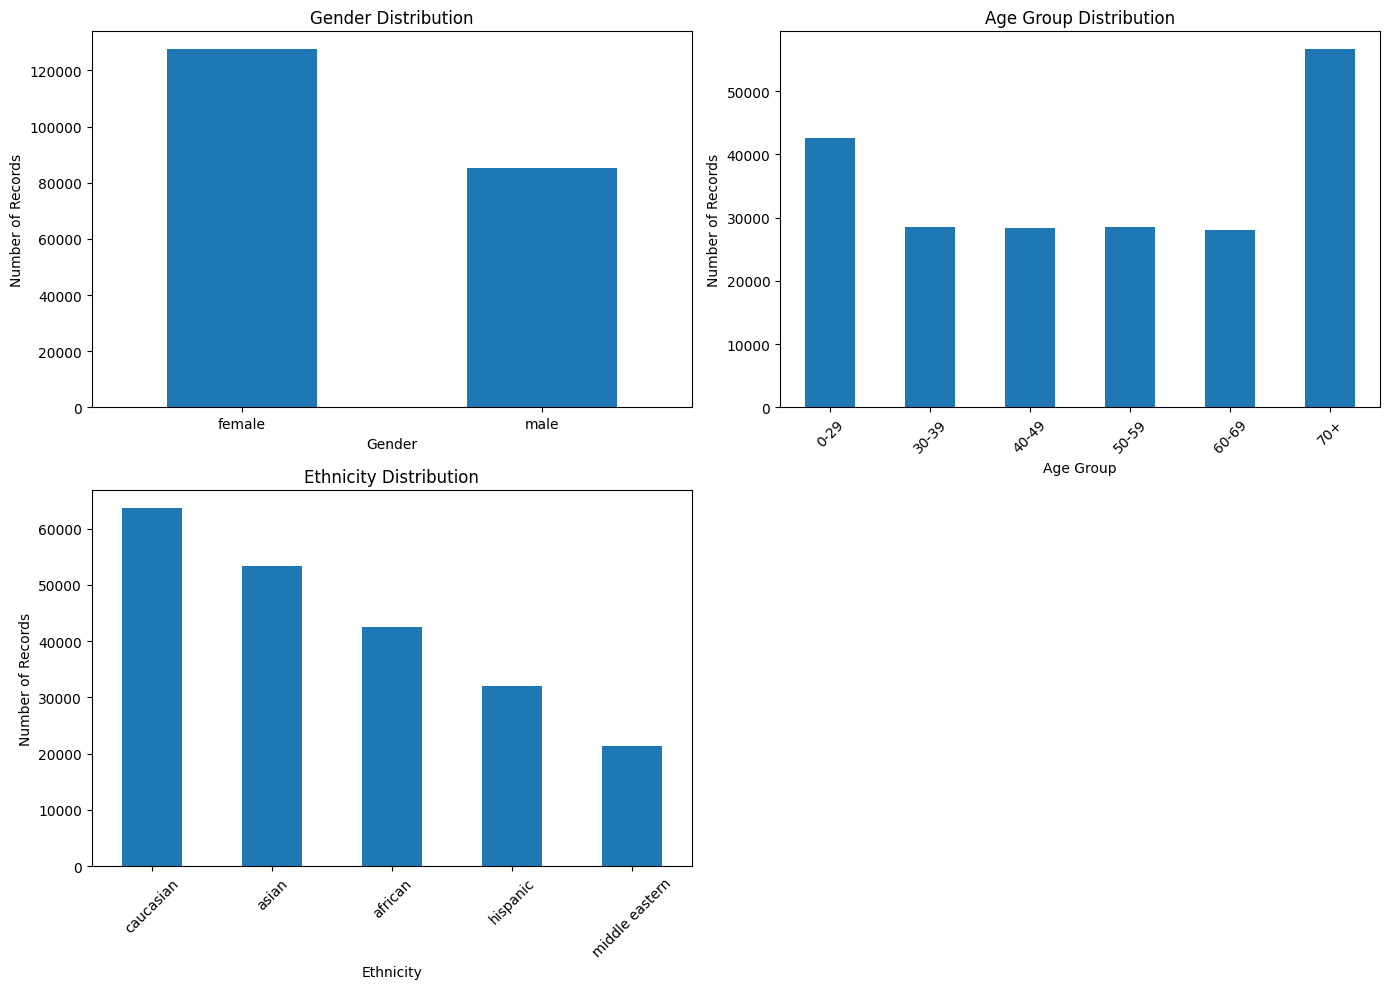

In [24]:
gender_counts = df_copy[GENDER_COL].value_counts().sort_index()

age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]
age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)

ethnicity_counts = df_copy[ETHNICITY_COL].value_counts().sort_values(ascending=False)

figure, axes = plt.subplots(2, 2, figsize=(14, 10))

gender_counts.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Gender Distribution")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].tick_params(axis="x", rotation=0)

age_group_counts.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Age Group Distribution")
axes[0, 1].set_xlabel("Age Group")
axes[0, 1].set_ylabel("Number of Records")
axes[0, 1].tick_params(axis="x", rotation=45)

ethnicity_counts.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Ethnicity Distribution")
axes[1, 0].set_xlabel("Ethnicity")
axes[1, 0].set_ylabel("Number of Records")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

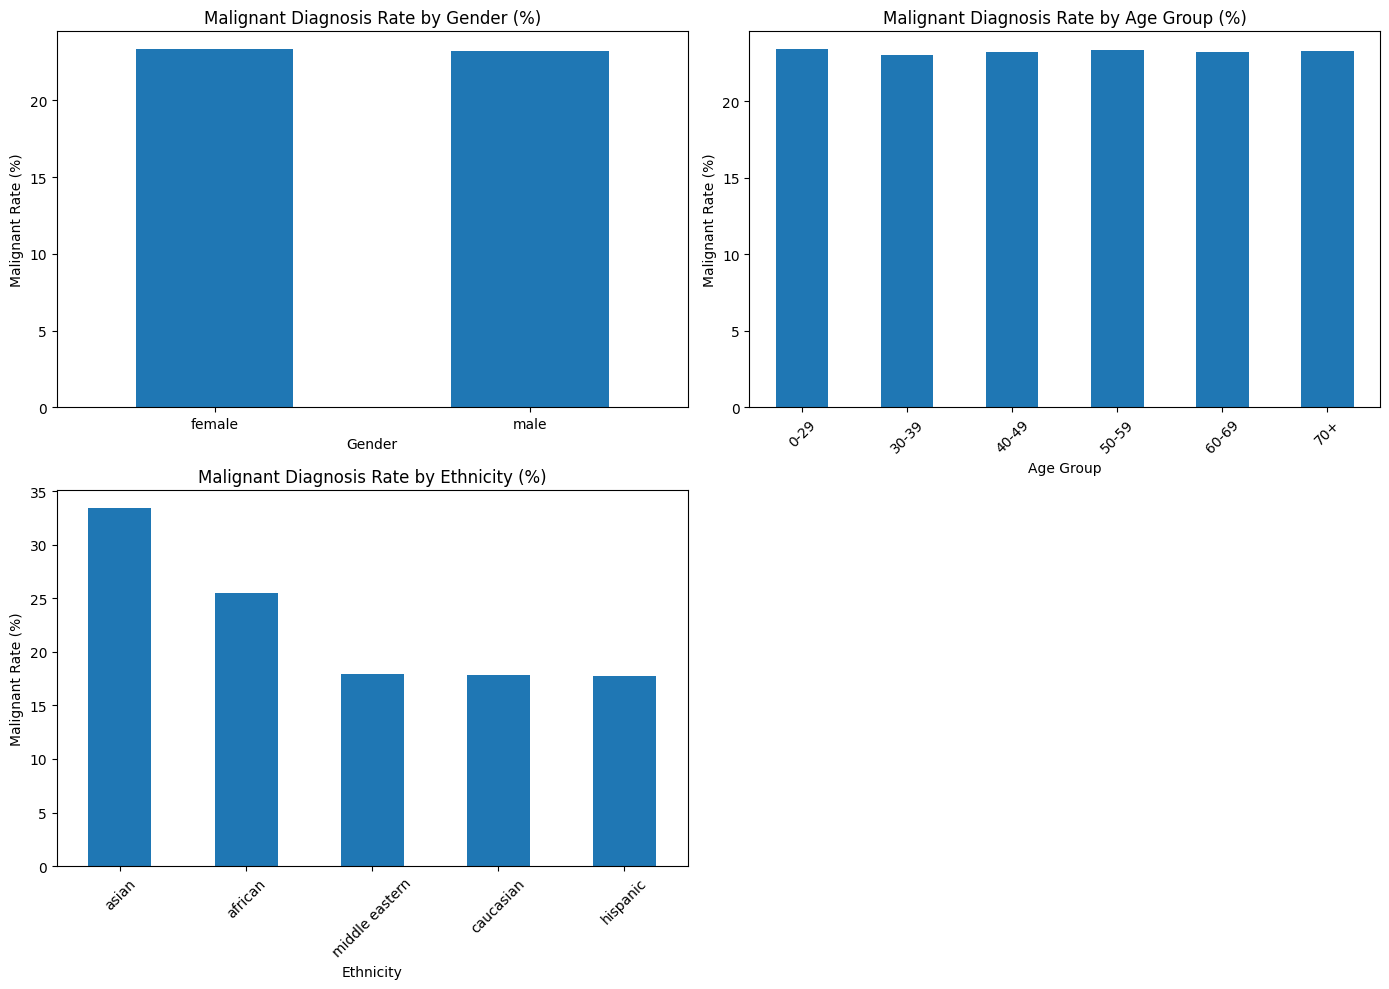

Ethnicity
asian             33.457877
african           25.472721
middle eastern    17.932974
caucasian         17.851702
hispanic          17.740222
Name: target, dtype: float64


In [45]:
gender_diagnosis_rate = df_copy.groupby(GENDER_COL)["target"].mean().sort_index() * 100
age_group_diagnosis_rate = (df_copy.groupby("Age_Group")["target"].mean().reindex(age_group_order, fill_value=0) * 100)
ethnicity_diagnosis_rate = (df_copy.groupby(ETHNICITY_COL)["target"].mean().sort_values(ascending=False) * 100)

figure, axes = plt.subplots(2, 2, figsize=(14,10))

gender_diagnosis_rate.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Malignant Diagnosis Rate by Gender (%)")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Malignant Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

age_group_diagnosis_rate.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Malignant Diagnosis Rate by Age Group (%)")
axes[0, 1].set_xlabel("Age Group")
axes[0, 1].set_ylabel("Malignant Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

ethnicity_diagnosis_rate.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Malignant Diagnosis Rate by Ethnicity (%)")
axes[1, 0].set_xlabel("Ethnicity")
axes[1, 0].set_ylabel("Malignant Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print(ethnicity_diagnosis_rate)

# Subgroup analysis of target prevalence

To explore potential fairness concerns within the dataset, the proportion of malignant diagnoses was examined across gender, age group, and ethnicity. The results indicate that malignant diagnosis prevalence is broadly stable across gender and age categories. Female participants had a malignant diagnosis rate of 23.32%, compared with 23.20% for males. Similarly, across all defined age groups, the malignant rate remained highly consistent, fluctuating only minimally between 23.02% and 23.39%.

In contrast, substantial variation was observed across ethnicity. The Asian subgroup exhibited the highest malignant diagnosis rate at 33.46%, followed by the African subgroup at 25.47%. Lower rates were observed among Middle Eastern (17.93%), Caucasian (17.85%), and Hispanic (17.74%) participants. This suggests that ethnicity is associated with a considerably greater difference in target prevalence than either gender or age.

This pattern is important from both a modelling and ethical perspective. Where a target label is distributed unevenly across demographic groups, predictive models may learn strong group-dependent associations. Such behaviour may improve apparent predictive accuracy while simultaneously increasing the risk of unfair or overly demographic-dependent decision making. Consequently, ethnicity should be treated as a key variable in subsequent fairness evaluation, particularly when assessing subgroup recall, false negative rates, and calibration.

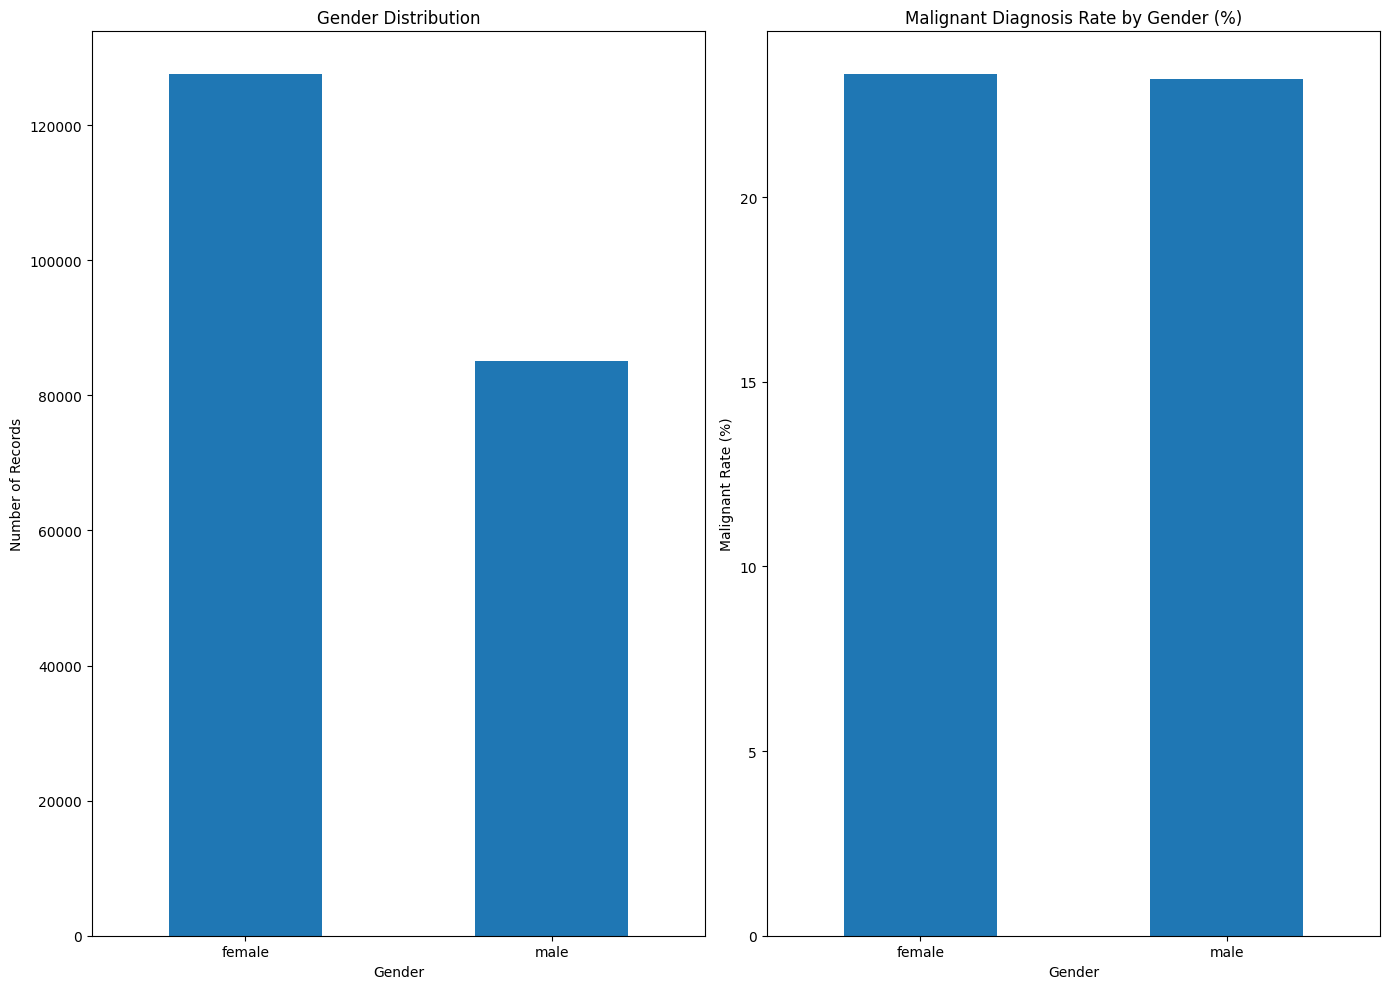

In [33]:
gender_counts = df_copy[GENDER_COL].value_counts().sort_index()
gender_malignant_rate = df_copy.groupby(GENDER_COL)["target"].mean().sort_index() * 100

figure, axes = plt.subplots(1, 2, figsize=(14, 10))

gender_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=0)

gender_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Gender (%)")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()



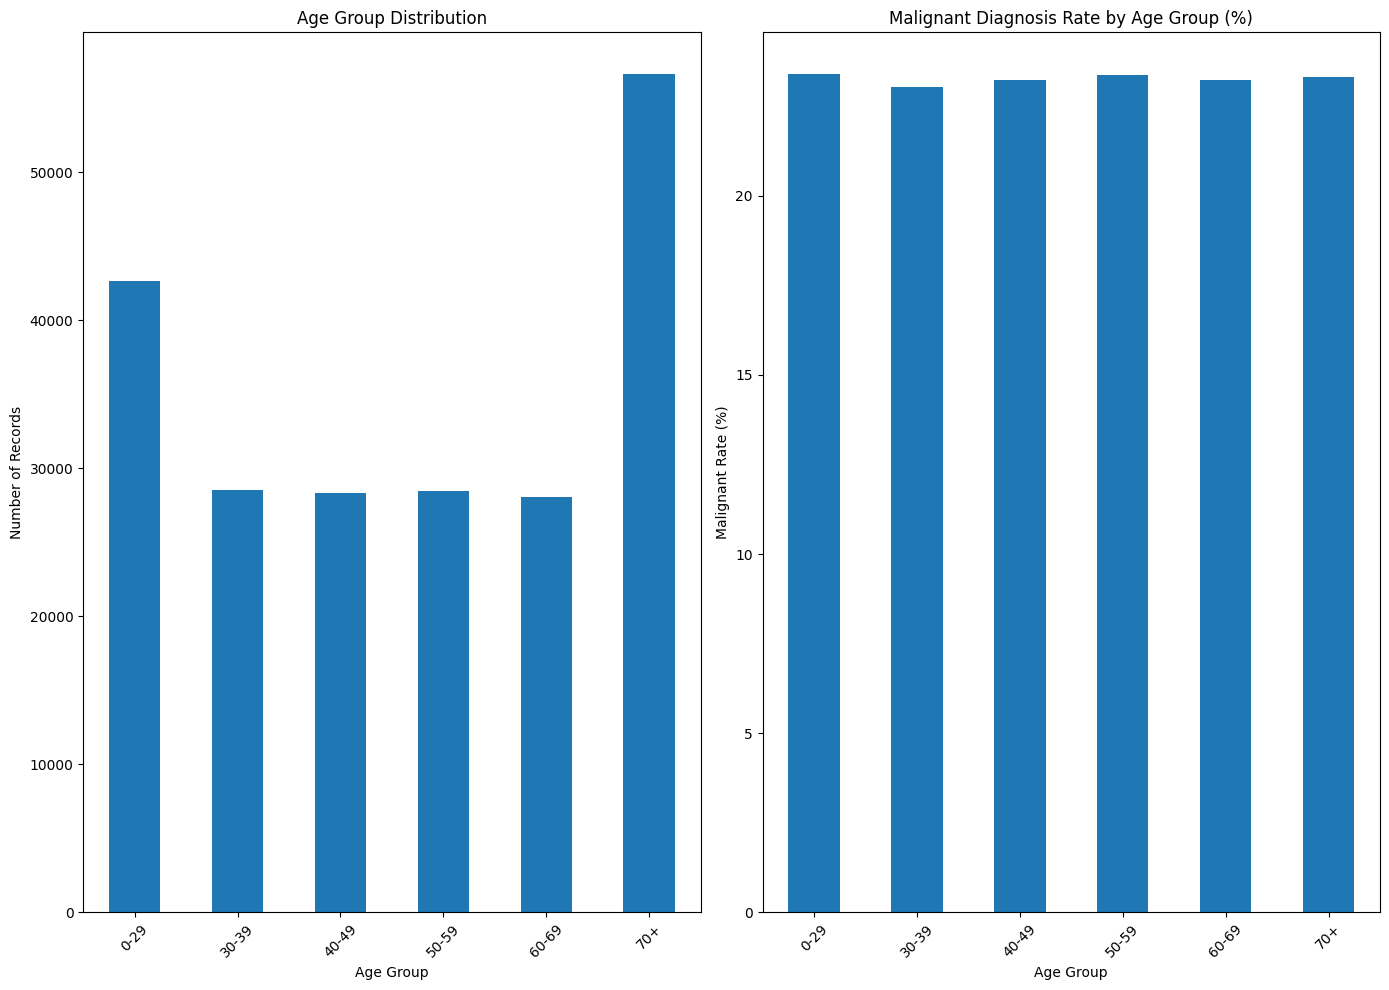

In [46]:
age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]

age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)
age_group_malignant_rate = (
    df_copy.groupby("Age_Group")["target"].mean().reindex(age_group_order, fill_value=0) * 100
)

figures, axes = plt.subplots(1, 2, figsize=(14, 10))

age_group_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Age Group Distribution")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=45)

age_group_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Age Group (%)")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

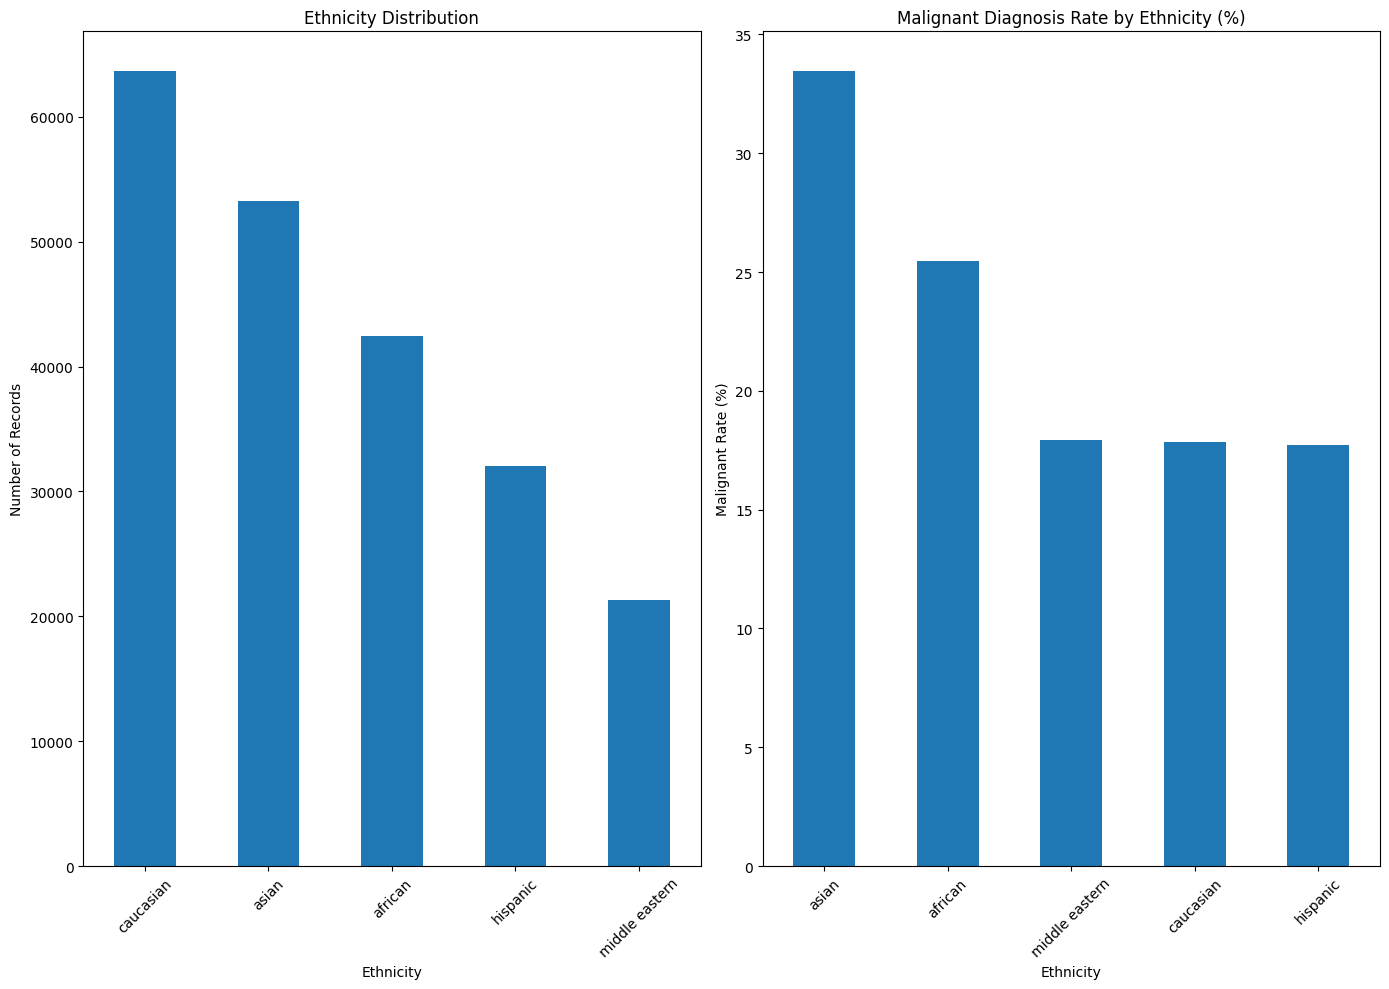

In [40]:
ethnicity_counts = df_copy[ETHNICITY_COL].value_counts().sort_values(ascending=False)
ethnicity_malignant_rate = (
    df_copy.groupby(ETHNICITY_COL)["target"].mean().sort_values(ascending=False) * 100
)

figure, axes = plt.subplots(1, 2, figsize=(14, 10))

ethnicity_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Ethnicity Distribution")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=45)

ethnicity_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Ethnicity (%)")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [41]:
gender_ethnicity_counts = pd.crosstab(df_copy[GENDER_COL], df_copy[ETHNICITY_COL])
print(gender_ethnicity_counts)

gender_age_counts = pd.crosstab(df_copy[GENDER_COL], df_copy["Age_Group"])
print("Gender x Age Group counts:")
print(gender_age_counts)

gender_ethnicity_malignant_rate = pd.crosstab(df_copy[GENDER_COL], df_copy[ETHNICITY_COL], values=df_copy["target"], aggfunc="mean") * 100
print(gender_ethnicity_malignant_rate)

gender_age_malignant_rate = pd.crosstab(df_copy[GENDER_COL], df_copy["Age_Group"], values=df_copy["target"], aggfunc="mean") * 100
print("Gender x Age Group malignant rate (%):")
print(gender_age_malignant_rate)

Ethnicity  african  asian  caucasian  hispanic  middle eastern
Gender                                                        
female       25519  31958      38035     19230           12785
male         16895  21303      25634     12782            8550
Gender x Age Group counts:
Age_Group   0-29  30-39  40-49  50-59  60-69    70+
Gender                                             
female     25533  17097  16994  17168  16844  33891
male       17124  11409  11367  11326  11211  22727
Ethnicity    african      asian  caucasian   hispanic  middle eastern
Gender                                                               
female     25.475136  33.700482  17.780991  17.763911       17.911615
male       25.469074  33.093930  17.956620  17.704585       17.964912
Gender x Age Group malignant rate (%):
Age_Group       0-29      30-39      40-49      50-59      60-69        70+
Gender                                                                     
female     23.279677  23.144411  23.520066

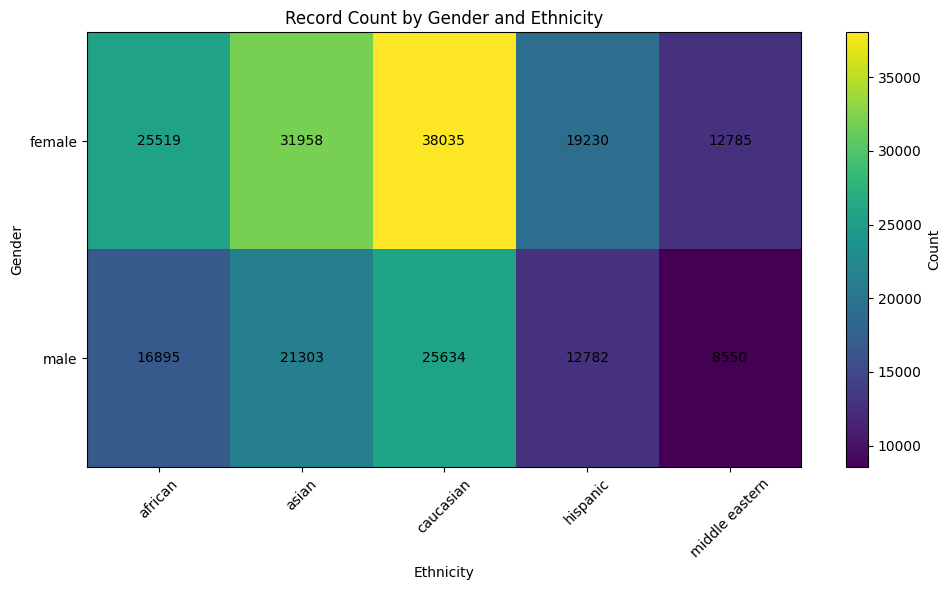

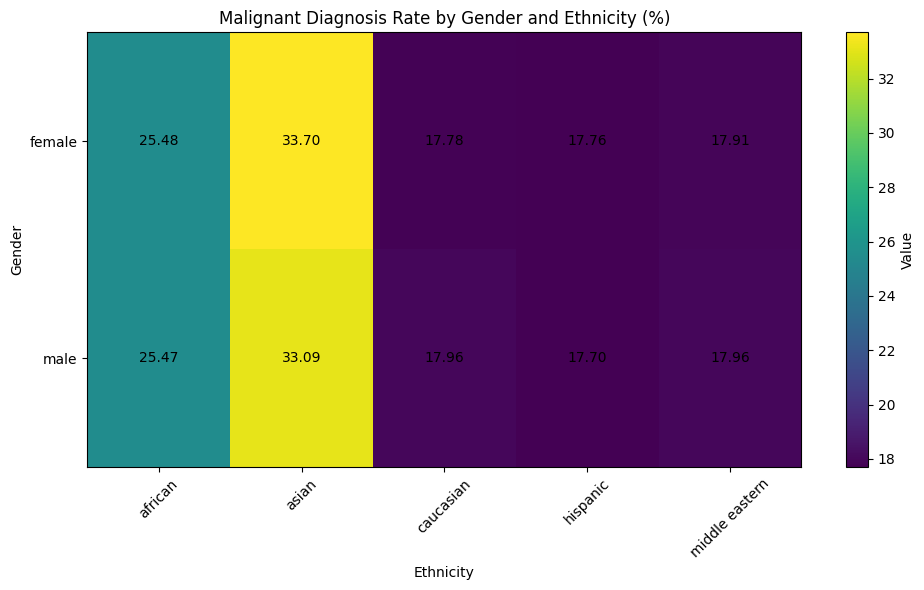

In [50]:
plot_heatmap(
    gender_ethnicity_counts,
    title="Record Count by Gender and Ethnicity",
    x_label="Ethnicity",
    y_label="Gender",
    colorbar_label="Count",
    decimal_places=0
)

plot_heatmap(
    gender_ethnicity_malignant_rate,
    title="Malignant Diagnosis Rate by Gender and Ethnicity (%)",
    x_label="Ethnicity",
    y_label="Gender",
    decimal_places=2
)

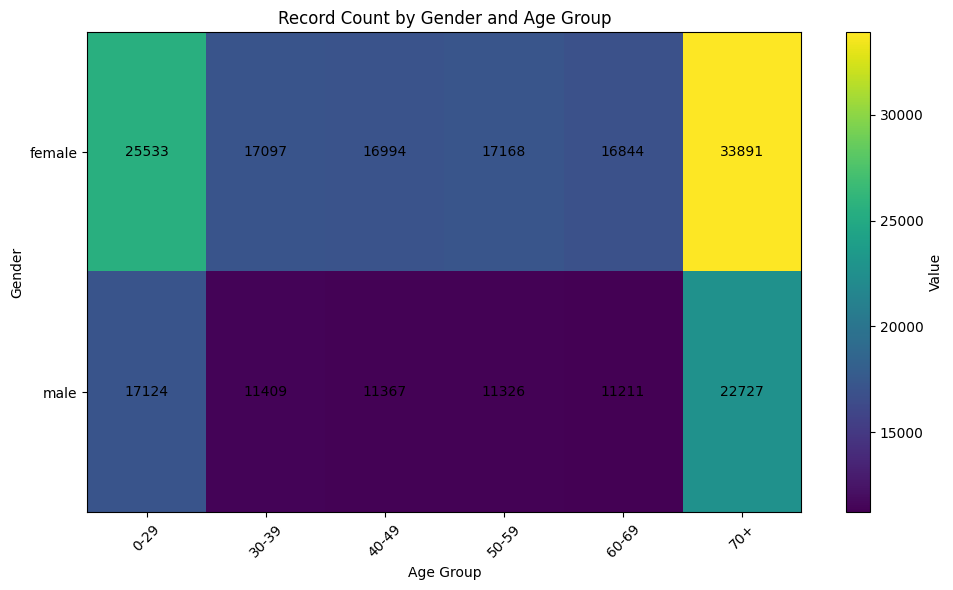

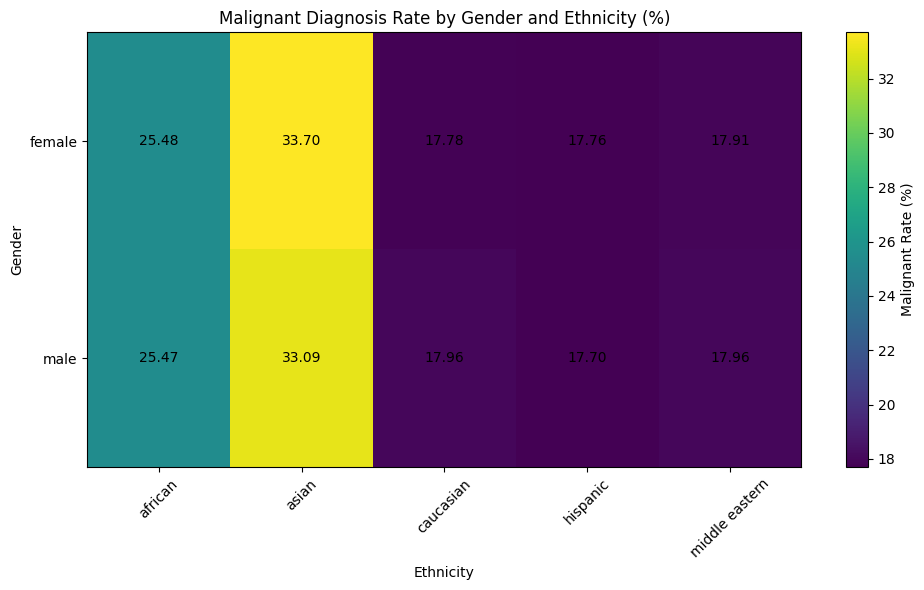

In [51]:
plot_heatmap(
    gender_age_counts,
    title="Record Count by Gender and Age Group",
    x_label="Age Group",
    y_label="Gender",
    decimal_places=0
)

plot_heatmap(
    gender_ethnicity_malignant_rate,
    title="Malignant Diagnosis Rate by Gender and Ethnicity (%)",
    x_label="Ethnicity",
    y_label="Gender",
    colorbar_label="Malignant Rate (%)",
    decimal_places=2
)

# Intersectional subgroup analysis

To extend the initial subgroup audit, an intersectional analysis was conducted across gender and ethnicity, and across gender and age group. This was undertaken to determine whether disparities that appeared modest at the single-group level became more pronounced when demographic characteristics were considered jointly.

The results indicate that, although the dataset contains more female than male records, the prevalence of malignant diagnosis is highly consistent between genders within each ethnicity group. For example, the malignant rate among African participants was 25.48% for females and 25.47% for males, while the corresponding rates among Asian participants were 33.70% and 33.09%. Similar consistency was observed for Caucasian, Hispanic, and Middle Eastern groups, all of which showed only minor differences between male and female participants.

A similarly stable pattern was observed across gender and age groups. Malignant diagnosis prevalence remained close to 23% across all age categories for both male and female participants, with only very small fluctuations. This suggests that age-group-related variation in the target label is limited when age is grouped in the current manner.

In contrast, ethnicity remains the most prominent source of variation in target prevalence. The Asian subgroup exhibits a substantially higher malignant diagnosis rate than all other ethnic groups, and this pattern is present in both females and males. This indicates that the observed ethnicity-based difference is not explained by gender composition alone. From a fairness perspective, this is important because a predictive model may learn strong ethnicity-dependent associations, which could influence model behaviour across demographic groups.

Overall, the intersectional analysis suggests that the principal source of demographic variation in the target variable is ethnicity rather than gender or age group. Consequently, ethnicity should be prioritised in subsequent fairness evaluation, particularly when assessing subgroup recall, false negative rate, and calibration.

### Selection of Ethnicity for Further Fairness Analysis

Following the initial subgroup and intersectional analysis, ethnicity was selected as the primary characteristic for further fairness investigation. This decision was based on the observation that malignant diagnosis prevalence varied much more substantially across ethnic groups than across gender or age groups.

The earlier descriptive analysis showed that gender and age-group malignant rates were relatively stable, with only small differences between subgroups. In contrast, ethnicity demonstrated notable variation in the proportion of malignant cases, with the Asian subgroup showing a considerably higher malignant rate than the other ethnic categories. This pattern also remained visible when ethnicity was examined in combination with gender, suggesting that the variation was not simply explained by differences in gender composition.

From an ethical and machine learning perspective, this is important because a predictive model trained on such data may learn strong subgroup-dependent associations. As a result, ethnicity represents the most appropriate characteristic for deeper analysis in this study, particularly when examining feature distributions, model behaviour, and subgroup fairness metrics.

               TSH_Level                   T3_Level                   \
                    mean median       std      mean median       std   
Ethnicity                                                              
african         5.049453   5.04  2.854871  2.004069   2.01  0.864386   
asian           5.042225   5.04  2.865765  1.998966   2.00  0.866082   
caucasian       5.039316   5.04  2.854553  2.003625   2.01  0.865208   
hispanic        5.050922   5.06  2.873013  2.002185   1.99  0.870789   
middle eastern  5.052167   5.04  2.855302  1.997608   2.00  0.866677   

                T4_Level                  Nodule_Size                   
                    mean median       std        mean median       std  
Ethnicity                                                               
african         8.258766   8.27  2.158672    2.496954   2.51  1.449804  
asian           8.246782   8.24  2.160700    2.508584   2.51  1.448077  
caucasian       8.238778   8.23  2.169489    2.511420   2.

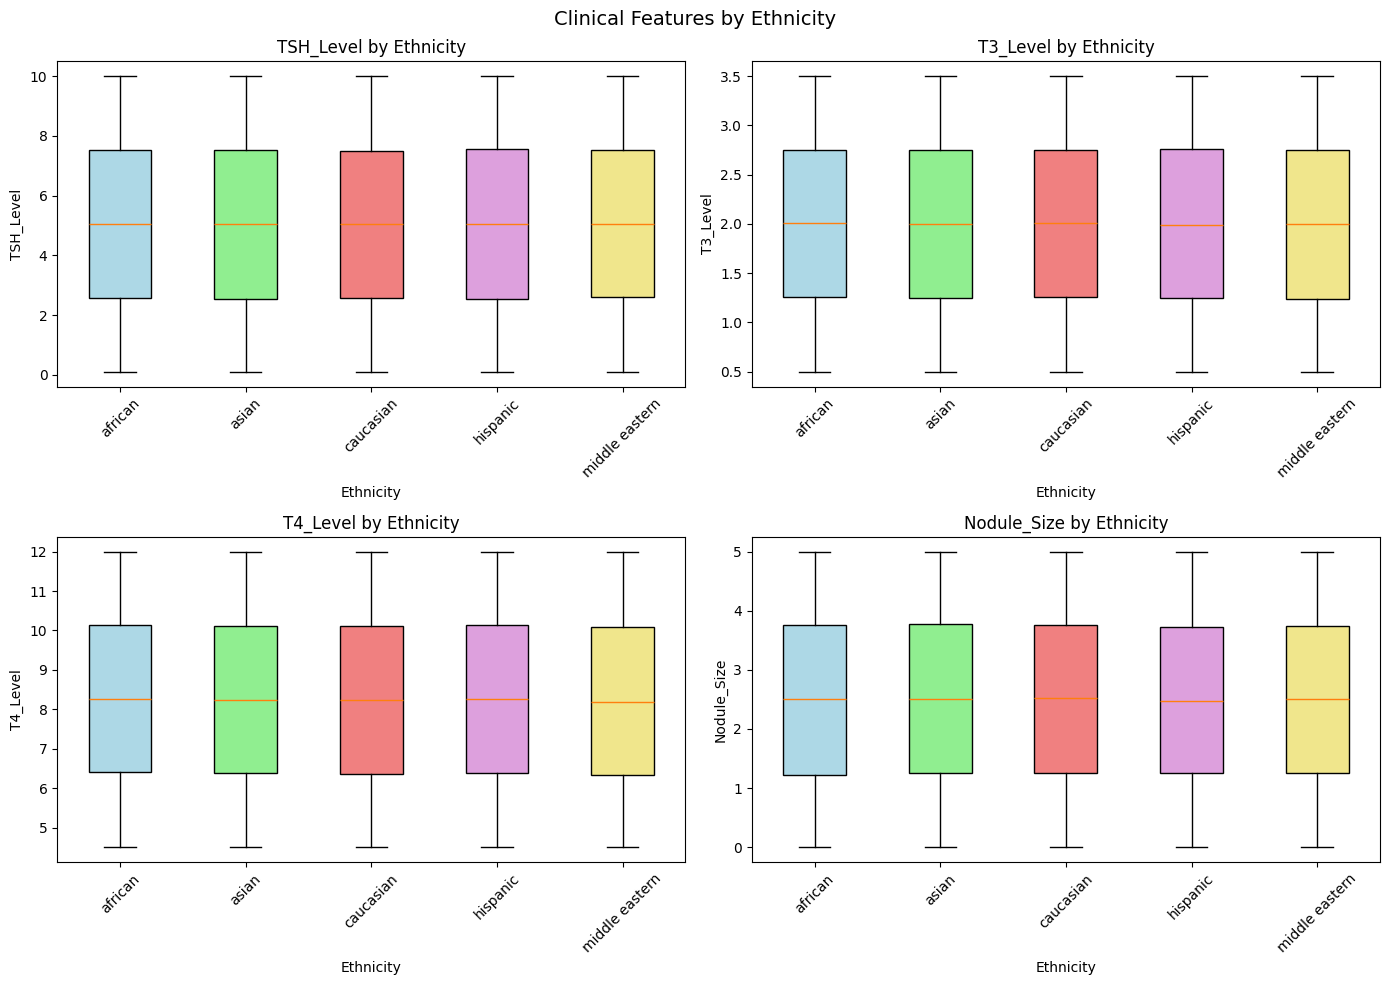

In [43]:
clinical_features = ["TSH_Level", "T3_Level", "T4_Level", "Nodule_Size"]
ethnicity_feature_summary = df_copy.groupby(ETHNICITY_COL)[clinical_features].agg(["mean", "median", "std"])
print(ethnicity_feature_summary)

figure, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

ethnicity_order = ["african", "asian", "caucasian", "hispanic", "middle eastern"]
box_colours = ["lightblue", "lightgreen", "lightcoral", "plum", "khaki"]

for index, feature_name in enumerate(clinical_features):
    grouped_values = [
        df_copy[df_copy[ETHNICITY_COL] == ethnicity_name][feature_name]
        for ethnicity_name in ethnicity_order
    ]
    
    boxplot = axes[index].boxplot(
        grouped_values,
        tick_labels=ethnicity_order,
        patch_artist=True
    )
    
    for box, colour in zip(boxplot["boxes"], box_colours):
        box.set_facecolor(colour)

    axes[index].set_title(f"{feature_name} by Ethnicity")
    axes[index].set_xlabel("Ethnicity")
    axes[index].set_ylabel(feature_name)
    axes[index].tick_params(axis="x", rotation=45)

figure.suptitle("Clinical Features by Ethnicity", fontsize=14)
plt.tight_layout()
plt.show()

### Comparison of Clinical Features Across Ethnic Groups

To investigate whether the observed differences in malignant diagnosis prevalence might be associated with underlying variation in clinical features, boxplots were produced for TSH level, T3 level, T4 level, and nodule size across ethnic groups.

The descriptive summary statistics indicated that the central tendencies of these variables were highly similar across ethnic categories. Mean and median values for TSH, T3, T4, and nodule size showed only minor variation, and the standard deviations were also broadly consistent between groups. If the boxplots reflect the same pattern, this would suggest that the major differences in malignant diagnosis prevalence across ethnicity are not clearly explained by large differences in these average clinical measurements alone.

This finding is relevant from a fairness perspective. If ethnic groups display similar distributions for several important clinical variables, yet still show different malignant outcome prevalence, then a predictive model may learn subgroup-dependent associations that are not immediately explained by simple feature averages. This strengthens the case for further model-based fairness evaluation focused on ethnicity.

### TensorBoard and What-If Tool Setup Check

Before building predictive models, TensorBoard and the What-If Tool were tested to confirm that the environment was correctly configured for later experiment tracking and interactive model inspection.

In [ ]:
%load_ext tensorboard

In [ ]:
log_dir = os.path.join(
    "/workspace/ethics_of_ai/logs/fit",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

os.makedirs(log_dir, exist_ok=True)
print(log_dir)

In [ ]:
writer = tf.summary.create_file_writer(log_dir)

with writer.as_default():
    for step in range(5):
        tf.summary.scalar("test_metric", step * 0.1, step=step)

print("Test TensorBoard logs written.")

In [ ]:
%tensorboard --logdir /workspace/ethics_of_ai/logs/fit

In [ ]:
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

print("What-If Tool imported successfully.")